<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK10_2_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7.5 LSTM

- RNN은 가중치가 업데이트되는 과정에서 기울기가 1보다 작은 값이 계속 곱해지기에 기울기 소멸 문제가 발생
- 이를 해결하기 위해 LSTM이나 GRU 같은 확장된 RNN 사용

## 7.5.1 LSTM 구조

- LSTM 순전파
- LSTM 역전파  

### LSTM 순전파

**< 망각 게이트 >**
- 과거 정보를 어느 정도 기억할지 결정
- 과거 정보와 현재 데이터를 입력받아 시그모이드를 취한 후 그 값을 과거 정보에 곱해 줌
- 시그모이드 출력이 0이면 과거 정보 버리고, 1이면 과거 정보 온전히 보존


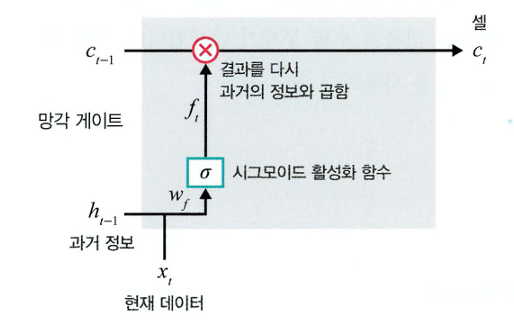

**< 입력 게이트 >**
- 현재 정보 기억을 위해 만들어짐
- 과거 정보와 현재 데이터를 입력받아 시그모이드와 하이퍼볼릭 탄젠트 함수를 기반으로 현재 정보에 대한 보존량 결정
- 즉, 현재 메모리에 새로운 정보를 반영할지 결정

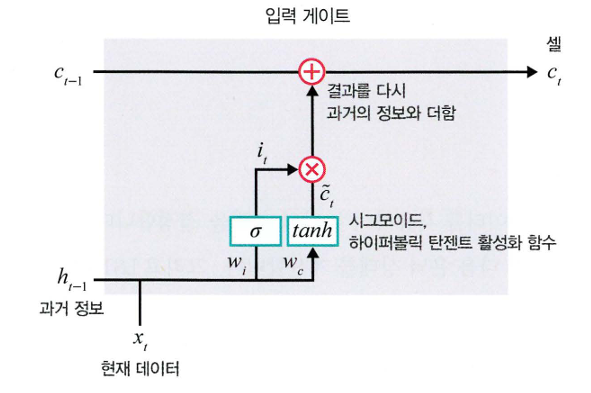

**< 출력 게이트 >**
-  과거 정보와 현재 데이터를 시용하여 뉴런의 출력을 결정
- 이전 은닉 상태와 t번째 입력을 고려해 다음 은닉 상태 계산
- LSTM에서는 이 은닉 상태가 그 시점에서의 출력이 됨
> LSTM이 내부 기억 c_t를 바탕으로 현재 시점에 외부로 내보내는 결과값이 h_t라는 뜻
- 계산한 값이 1이면 의미 있는 결과로 최종 출력, 0이면 해당 연산 출력을 하지 않음

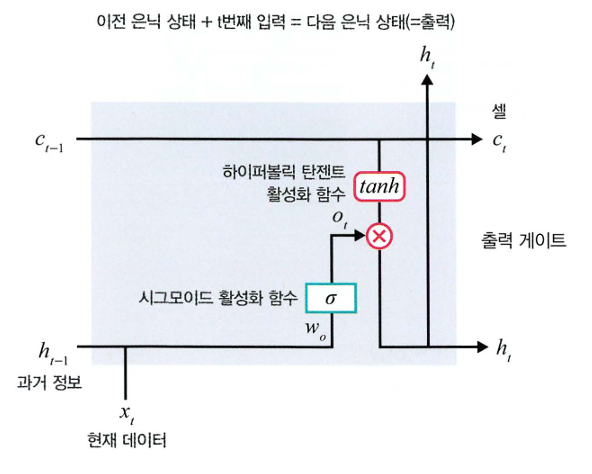

- h_t → 다음 시점 LSTM으로 전달
- h_t → 현재 시점의 출력으로 사용

< LSTM 전체 게이트 >

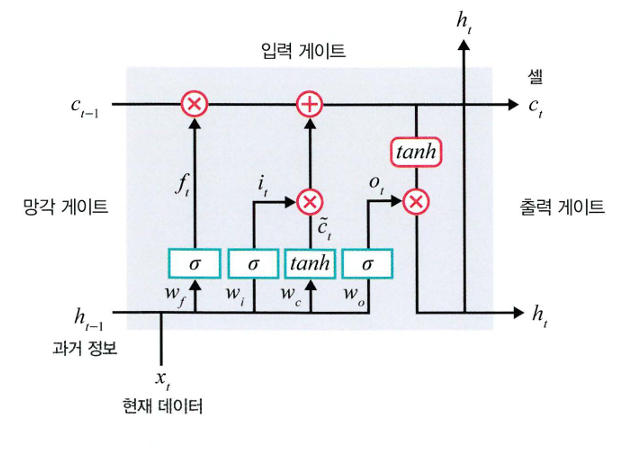

### LSTM 역전파

- 셀을 통해 역전파 수행
- 최종 오차는 모든 노드에 전파되는데, 이때 셀을 통해 중단 없이 전파됨
> 셀 = 각 단계에 대한 은닉 노드를 메모리 셀이라고 함

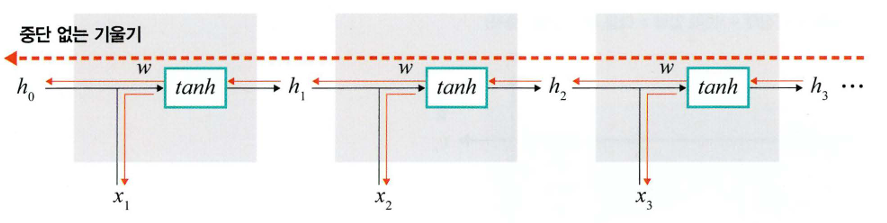

## 7.5.2 LSTM 셀구현

In [1]:
# 7-29 라이브러리 호출
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter  # 파라미터 목록을 가지고 있는 라이브러리
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math  # 수학과 관련되어 다양한 함수들과 상수들이 정의되어 있는 라이브러리

device = torch.device( 'cuda:8' if torch.cuda.is_available() else 'cpu' )
cuda = True if torch.cuda.is_available() else False

Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor  # GPU 사용에 필요

torch.manual_seed(125)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(125)

In [2]:
# 7-30 데이터 전처리
import torchvision.transforms as transforms
mnist_transform = transforms.Compose([
    transforms.ToTensor() ,
    transforms.Normalize( (0.5, ), (1.0, ))  # 평균을 0.5, 표준편차를 1.0으로 데이터 정규화
    ])

In [3]:
# 7-31 데이터셋 내려받기
from torchvision.datasets import MNIST

download_root = '/content/drive/MyDrive/ESAA/MNIST_DATASET'
train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True)
valid_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.13MB/s]


In [4]:
# 7-32 데이터셋을 메모리로 가져오기
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

In [5]:
# 7-33 변수 값 지정
batch_size = 100
n_iters = 6000
num_epochs = n_iters/(len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

In [6]:
# 7-34 LSTM 셀 네트워크 구축
class LSTMCell(nn.Module) :
    def __init__(self, input_size, hidden_size, bias=True) :
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bias = bias
        self.x2h = nn.Linear(input_size, 4*hidden_size, bias=bias)
        self.h2h = nn.Linear(hidden_size, 4*hidden_size, bias=bias)
        self.reset_parameters()

    def reset_parameters(self) : # 모델 파라미터 초기화
        std = 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters() :
            w.data.uniform_(-std, std) # 난수생성

    def forward(self, x, hidden) :
        hx, cx = hidden
        x = x.view(-1, x.size(1))

        gates = self.x2h(x) + self.h2h(hx) # 모든 게이트를 구하는 코드
        gates = gates.squeeze() # 텐서 차원 감소
        ingate, forgetgate, cellgate, outgate = gates.chunk(4, 1)

        ingate = F.sigmoid(ingate) # 입력 게이트에 시그모이드 적용
        forgetgate = F.sigmoid(forgetgate) # 망각 게이트에 시그모이드 적용
        cellgate = F.tanh(cellgate) # 셀 게이트에 탄젠트 적용
        outgate = F.sigmoid(outgate) # 출력 게이트에 시그모이드 적용

        cy = torch.mul(cx, forgetgate) + torch.mul(ingate, cellgate) # 텐서 곱셈
        hy = torch.mul(outgate, F.tanh(cy))

        return (hy, cy)

In [7]:
# 7-35 LSTM 셀의 전반적인 네트워크 구축
class LSTMModel(nn.Module) :
   def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, bias=True) :
       super(LSTMModel, self).__init__()
       self.hidden_dim = hidden_dim # 은닉층 뉴런, 유닛 개수

       self.layer_dim = layer_dim
       self.lstm = LSTMCell(input_dim, hidden_dim, layer_dim) # 앞에서 정의한 함수 불러오기
       self.fc = nn.Linear(hidden_dim, output_dim)

   def forward(self, x) :
       if torch.cuda.is_available() :
           h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
       else :
           h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

       if torch.cuda.is_available() :
           c0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
       else :
           c0 = Variable(torch.zeros(self.layer_dim, x.size(0), hidden_dim))

       outs = []
       cn =  c0[0,:,:]
       hn = h0[0,:,:]

       for seq in range(x.size(1)) : #LSTM 겔 계층 반복해 쌓음
           hn, cn = self.lstm(x[:, seq, :], (hn, cn))
           outs.append(hn)

       out = outs[-1].squeeze()
       out = self.fc(out)
       return out

In [8]:
# 7-36 옵티마이저, 손실 함수 지정
input_dim = 28
hidden_dim = 128
layer_dim = 1
output_dim = 18

model =  LSTMModel(input_dim, hidden_dim, layer_dim, output_dim)
if torch.cuda.is_available() :
   model.cuda()

criterion = nn.CrossEntropyLoss()
learning_rate =0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [9]:
# 7-37 모델 학습 및 성능 확인
seq_dim=28
loss_list = []
iter = 0
for epoch in range(num_epochs) :
   for i, (images ,labels) in enumerate(train_loader) :  # 훈련 데이터셋을 이용한 모델 학습
       if torch.cuda.is_available() :
           images = Variable(images.view(-1, seq_dim, input_dim).cuda())
           labels = Variable(labels.cuda())

       else :
           images = Variable(images.view(-1, seq_dim, input_dim))
           labels = Variable(labels)

       optimizer.zero_grad()
       outputs = model(images)
       loss = criterion(outputs, labels)

       if torch.cuda.is_available() :
           loss.cuda()

       loss.backward()
       optimizer.step()
       loss_list.append(loss.item())
       iter += 1


       if iter % 500 == 0 :
           correct = 0
           total = 0

           for images, labels in valid_loader :

               if torch.cuda.is_available() :
                   images = Variable(images.view(-1, seq_dim, input_dim).cuda())
               else :
                   images = Variable(images.view(-1, seq_dim, input_dim))

               outputs = model(images)
               _, predicted = torch.max(outputs.data, 1)

               total += labels.size(0)
               if torch.cuda.is_available() :
                   correct += (predicted.cpu() == labels.cpu()).sum()

               else :
                   correct += (predicted == labels).sum()

           accuracy = 100 * correct / total
           print(f'Iteration : {iter} Loss : {loss.item()} Accuracy : {accuracy}')

Iteration : 500 Loss : 2.1593682765960693 Accuracy : 29.709999084472656
Iteration : 1000 Loss : 0.7015144228935242 Accuracy : 79.2300033569336
Iteration : 1500 Loss : 0.29872792959213257 Accuracy : 89.3499984741211
Iteration : 2000 Loss : 0.11103250086307526 Accuracy : 94.27999877929688
Iteration : 2500 Loss : 0.059900712221860886 Accuracy : 95.19999694824219
Iteration : 3000 Loss : 0.07249211519956589 Accuracy : 96.27999877929688
Iteration : 3500 Loss : 0.16951099038124084 Accuracy : 95.91999816894531
Iteration : 4000 Loss : 0.14313192665576935 Accuracy : 97.12000274658203
Iteration : 4500 Loss : 0.062153127044439316 Accuracy : 97.19000244140625
Iteration : 5000 Loss : 0.04350724816322327 Accuracy : 97.2300033569336
Iteration : 5500 Loss : 0.005144677124917507 Accuracy : 97.55999755859375
Iteration : 6000 Loss : 0.08789943903684616 Accuracy : 97.4000015258789
Iteration : 6500 Loss : 0.013630064204335213 Accuracy : 97.97000122070312
Iteration : 7000 Loss : 0.03166550025343895 Accuracy 

In [10]:
# 7-38 테스트 데이터셋으로 성능 확인
def evaluate(model, val_iter) :
    corrects, total, total_loss = 0, 0, 0
    model.eval()
    for images, labels in val_iter :
        if torch.cuda.is_available() :
            images = Variable(images.view(-1, seq_dim, input_dim).cuda())
            labels = labels.cuda()
        else :
            images = Variable(images.view(-1, seq_dim, input_dim).to(device))
            labels = labels.to(device)

        logit = model(images).to(device)
        loss = F.cross_entropy(logit, labels, reduction='sum') # 모든 오차 총합
        _, predicted = torch.max(logit.data, 1)
        total += labels.size(0)
        total_loss += loss.item()
        corrects += (predicted == labels).sum()

    avg_loss = total_loss / len(val_iter.dataset)
    avg_accuracy = corrects / total
    return avg_loss, avg_accuracy

In [11]:
# 7-39 모델 예측 성능 확인
test_loss, test_acc = evaluate(model, test_loader)
print("Test Loss : %5.2f | Test Accuracy: %5.2f" % (test_loss, test_acc))

Test Loss :  0.06 | Test Accuracy:  0.98


## 7.5.3 LSTM 계층 구현

In [12]:
# 7-40 라이브러리 호출
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [13]:
# 7-41 데이터셋 가져오기
!git clone https://github.com/gilbutITbook/080289.git
data_path = './080289/chap07/data/SBUX.csv'
data = pd.read_csv(data_path)

print(data.dtypes)

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 2278 (delta 1), reused 0 (delta 0), pack-reused 2273 (from 2)
Receiving objects: 100% (2278/2278), 330.30 MiB | 29.09 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [14]:
# 7-42 날짜 칼럼을 인덱스로 사용
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [16]:
# 7-43 데이터 형식 변경
data['Volume'] = data['Volume'].astype(float)

In [17]:
# 7-44 훈련, 레이블 분리
X = data.iloc[:, :-1]  # 마지막 칼럼을 제외한 모든 칼럼을 x로 사용
y = data.iloc[:, 5:6]  # 마지막 Volume을 레이블로 사용
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

In [18]:
# 7-45 데이터 분포 조정
ms = MinMaxScaler()  # 데이터의 모든 값이 0~1 사이에 존재하도록 분산 조정
ss = StandardScaler()  # 데이터가 평균 0, 분산 1이 되도록 분산 조정

X_ss = ss.fit_transform(X)
y_ms = ms.fit_transform(y)

X_train = X_ss[:200, :]
X_test = X_ss[200:, :]

y_train = y_ms[:200, :]
y_test = y_ms[200:, :]

print("Training Shape" , X_train.shape, y_train.shape)
print("Testing Shape", X_test.shape, y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


In [19]:
# 7-46 데이터셋 형태 및 크기 조정
X_train_tensors = Variable(torch.Tensor(X_train))
# Variable로 감싸진 텐서는.backward()가 호출될 때 자동으로 기울기가 계산됨
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

# 형태를 (200,1,5)로 변경 > LSTM 네트워크의 입력 형태와 맞추기 위함
X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors.shape[0],
                                                    1, X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors.shape[0],
                                                  1, X_test_tensors.shape[1]))

print('Training Shape', X_train_tensors_f.shape, y_train_tensors.shape)
print('Testing Shape', X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [20]:
# 7-47 LSTM 네트워크
class LSTM(nn.Module) :
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length) :
        super(LSTM, self).__init__()
        self.num_classes = num_classes
        self.num_layers = num_layers # LSTM 계층 개수
        self.input_size = input_size # 입력 크기
        self.hidden_size = hidden_size # 은닉층 뉴런 개수
        self.seq_length = seq_length # 시퀀스 길이

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True) # LSTM 계층
        self.fc_1 = nn.Linear(hidden_size, 128) # 완전 연결층
        self.fc = nn.Linear(128, num_classes) # 출력층
        self.relu = nn.ReLU()

    def forward(self, x) :
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 은닉상태 0으로 초기화
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 셀 상태 0으로 초기화
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) # LSTM 계층에 은닉, 셀 상태 적용
        hn = hn.view(-1, self.hidden_size) # 데이터 형태 조정
        out = self.relu(hn)
        out = self.fc_1(out)
        out = self.relu(out)
        out = self.fc(out)
        return out

In [21]:
# 7-48 변수 값 설정
num_epochs = 1000
lr = 0.0001

input_size=5
hidden_size=2
num_layers=1

num_classes=1
model = LSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [22]:
# 7-49 모델 학습
for epoch in range(num_epochs) :
    outputs = model.forward(X_train_tensors_f) # 전방향 학습
    optimizer.zero_grad()
    loss = criterion(outputs, y_train_tensors)
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0 :
        print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.14250
Epoch: 100, loss: 0.01529
Epoch: 200, loss: 0.01107
Epoch: 300, loss: 0.01075
Epoch: 400, loss: 0.01071
Epoch: 500, loss: 0.01065
Epoch: 600, loss: 0.01085
Epoch: 700, loss: 0.01060
Epoch: 800, loss: 0.01073
Epoch: 900, loss: 0.01071


In [23]:
# 7-50 예측 결과 출력을 위한 데이터 크기 재구성
df_x_ss = ss.transform(data.iloc[:, :-1])  # 정규화
df_y_ms = ms.transform(data.iloc[:, -1:])  # 정규화

df_x_ss = Variable(torch.Tensor(df_x_ss))
df_y_ms = Variable(torch.Tensor(df_y_ms))
df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

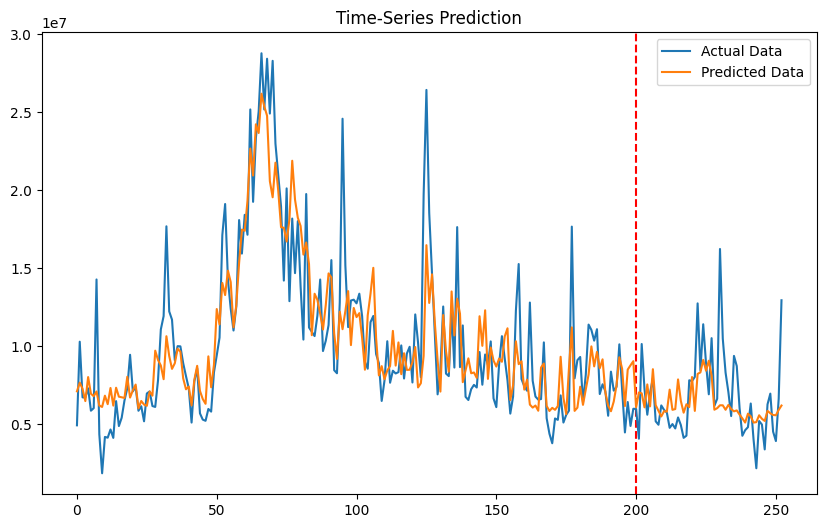

In [24]:
# 7-51 예측 결과 출력
train_predict = model(df_x_ss)
predicted = train_predict.data.numpy()
label_y = df_y_ms.data.numpy()

predicted = ms.inverse_transform(predicted)  # 모델 학습을 위해 정규화한 것 해제 > 그래프의 본 값 출력을 위해서
label_y = ms.inverse_transform(label_y)
plt.figure(figsize=(10, 6))
plt.axvline(x=200, c='r', linestyle='--')

plt.plot(label_y, label='Actual Data')
plt.plot(predicted, label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()